# Quantum approximate optimization algorithm

## Setup



In [1]:
import matplotlib
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator

In [2]:
import networkx as nx
import rustworkx as rx
import numpy as np
import matplotlib.pyplot as plt

def generate_deterministic_graph(n, degree=3, seed=42):
    """
    Generates a random regular graph (nodes have fixed number of connections).
    
    Args:
        n (int): Number of nodes
        degree (int): Number of edges per node (3 is standard for MaxCut benchmarks)
        seed (int): Seed for reproducibility
        
    Returns:
        rx.PyGraph: The graph ready for your pipeline
    """
    # 1. Use NetworkX to generate the structure (it has great generators)
    # 'random_regular_graph' creates a graph where every node has 'd' neighbors
    # This is much more realistic for QAOA than a complete graph.
    G_nx = nx.random_regular_graph(d=degree, n=n, seed=seed)

    # 2. Convert to Rustworkx (rx.PyGraph)
    graph_rx = rx.PyGraph()
    graph_rx.add_nodes_from(np.arange(0, n, 1))

    # 3. Add edges with weight 1.0
    # format: (start_node, end_node, weight)
    weighted_edges = [(u, v, 1.0) for u, v in G_nx.edges()]
    graph_rx.add_edges_from(weighted_edges)

    return graph_rx


Cost Function Hamiltonian: SparsePauliOp(['IIIIIZIIIIIIIIIZ', 'IIIIIIZIIIIIIIIZ', 'IIIZIIIIIIIIIIIZ', 'IIIIIIIIIIIIZIZI', 'IIIZIIIIIIIIIIZI', 'IIIIIZIIIIIIIIZI', 'IIIIIIIIIIZIIZII', 'IIIIIIIZIIIIIZII', 'IIIIIIIIIIIIZZII', 'IIIIIIIIIIIZZIII', 'IZIIIIIIIIIZIIII', 'IIIIZIIIIIIZIIII', 'IIIIIIIIIZZIIIII', 'ZIIIIIIIIIZIIIII', 'IIIIZIIIIZIIIIII', 'IZIIIIIIIZIIIIII', 'IIIIIZIIZIIIIIII', 'IIZIIIIIZIIIIIII', 'IIIZIIIIZIIIIIII', 'ZIIIIIIZIIIIIIII', 'IIIIZIIZIIIIIIII', 'IIZIIIZIIIIIIIII', 'ZIIIIIZIIIIIIIII', 'IZZIIIIIIIIIIIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


c:\Users\tomka\repos\Masters\MastersThesis\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -9.23076923076923
       x: [ 2.495e+00  2.716e+00  3.181e+00  4.376e+00]
    nfev: 28
   maxcv: 0.0


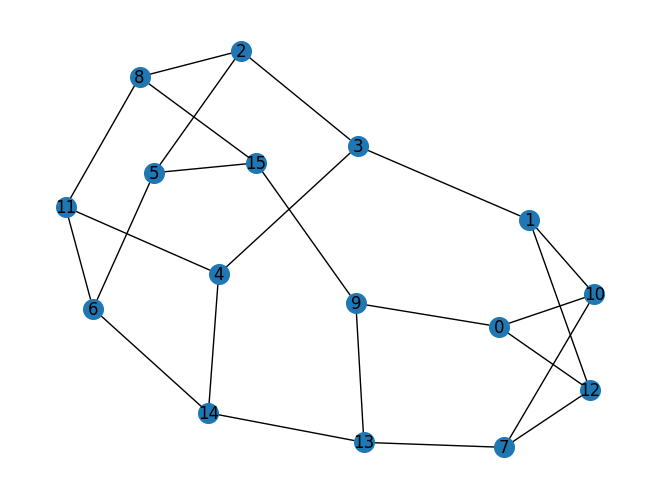

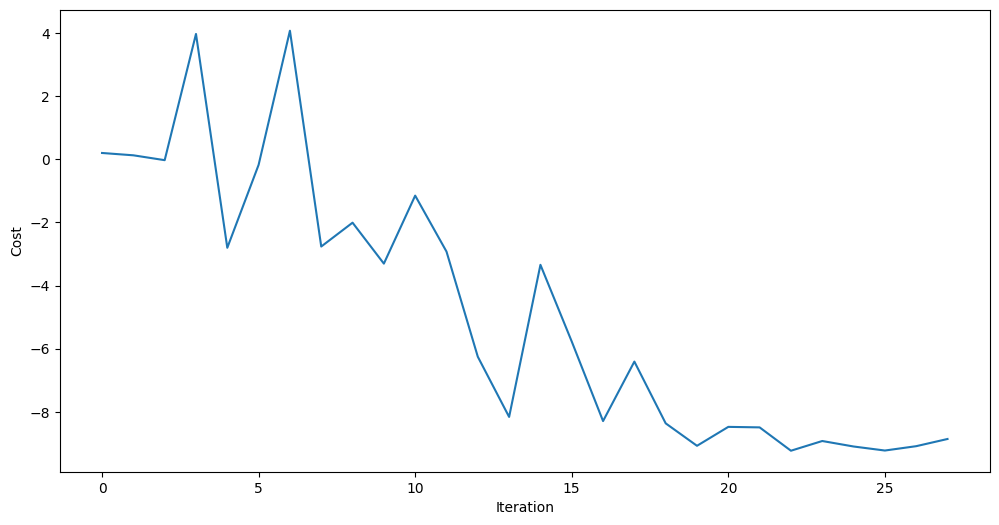

{2026: 0.0001, 10409: 0.0003, 57675: 0.0004, 32552: 0.0013, 48178: 0.0005, 43341: 0.0001, 17315: 0.0007, 24490: 0.0002, 907: 0.0001, 65332: 0.0001, 18981: 0.0002, 56872: 0.0008, 44117: 0.0003, 55477: 0.0001, 39258: 0.0001, 48212: 0.0008, 18344: 0.0006, 49331: 0.0005, 19078: 0.0002, 49367: 0.0013, 55305: 0.0001, 16883: 0.0001, 8562: 0.0002, 50633: 0.0004, 8647: 0.0002, 2034: 0.0006, 63724: 0.0001, 41275: 0.0001, 43031: 0.0007, 18875: 0.0003, 46554: 0.0002, 37612: 0.0001, 3688: 0.0001, 17321: 0.0004, 53686: 0.0001, 24104: 0.0019, 28587: 0.0001, 17101: 0.0002, 60455: 0.0002, 38917: 0.0002, 23572: 0.0002, 60844: 0.0001, 8611: 0.0001, 42450: 0.0002, 51631: 0.0002, 24524: 0.0001, 46424: 0.0033, 50552: 0.0001, 14571: 0.0001, 49337: 0.0001, 52171: 0.0001, 49863: 0.0001, 24326: 0.0002, 9750: 0.0001, 15666: 0.0003, 19370: 0.0017, 42233: 0.0001, 19095: 0.0002, 17387: 0.001, 47512: 0.0001, 50480: 0.0001, 32039: 0.0002, 56844: 0.0025, 29993: 0.0004, 19127: 0.001, 2259: 0.0001, 46393: 0.0001, 57949:

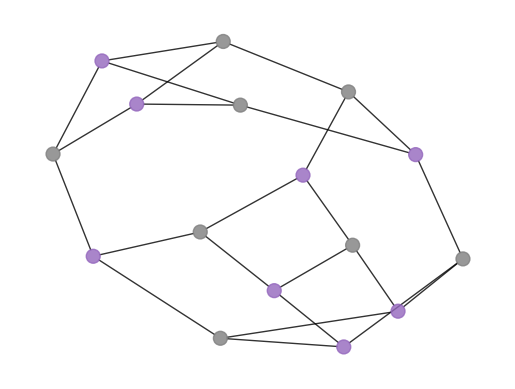

In [3]:
n = 16

# Generate the graph
graph = generate_deterministic_graph(n)

draw_graph(graph, node_size=200, with_labels=True, width=1)


def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

# Build the circuit - automatic!
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw("mpl")

circuit.parameters

# Simulator of the circuit
aer_sim = AerSimulator()
backend = aer_sim
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

objective_func_vals = []  # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

'''matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()'''

# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )


plot_result(graph, most_likely_bitstring)

def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(
        list(graph.nodes())
    ), "The length of x must coincide with the number of nodes in the graph."
    return sum(
        x[u] * (1 - x[v]) + x[v] * (1 - x[u])
        for u, v in list(graph.edge_list())
    )


cut_value = evaluate_sample(most_likely_bitstring, graph)
print("The value of the cut is:", cut_value)

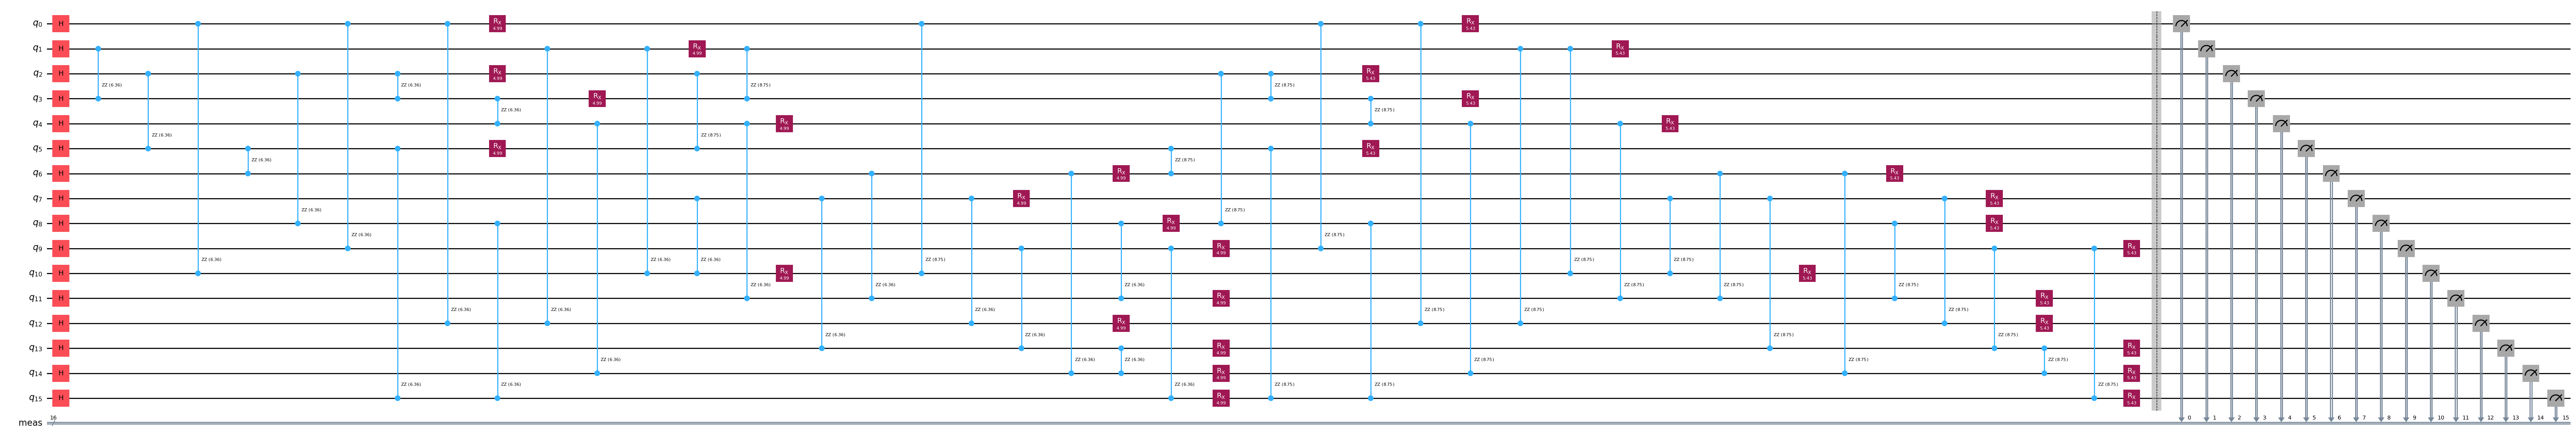

In [5]:
optimized_circuit.draw("mpl", fold=False, idle_wires=False)



ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...
-> Converted! Network has 160 tensors and 208 indices.


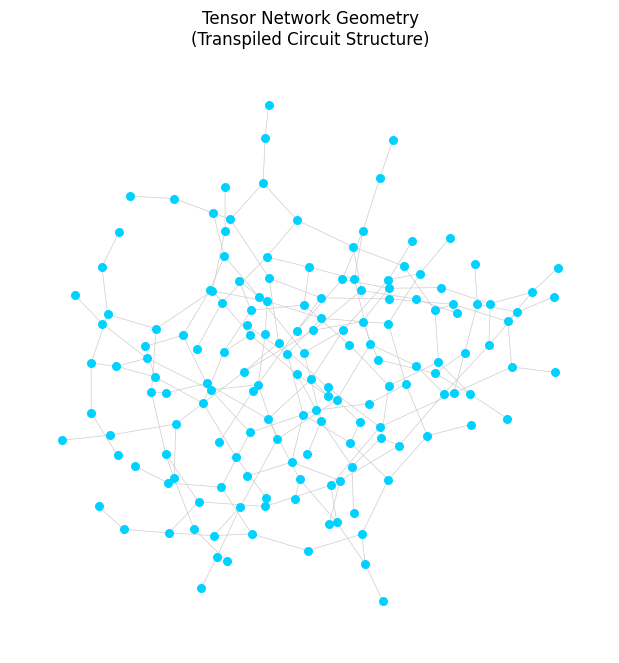


[Step 3] Attempting Naive Contraction...


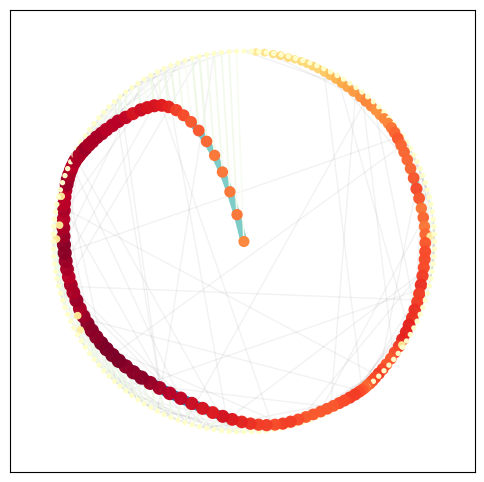

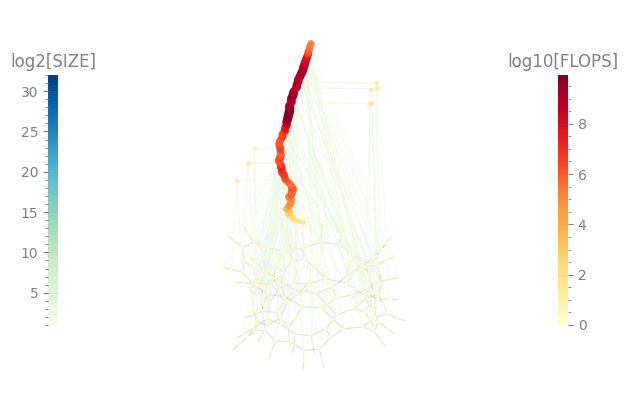


[Step 3B] Attempting CPU Contraction...


F=7.56 C=7.80 S=17.00 P=18.09: 100%|██████████| 32/32 [00:00<00:00, 493.93it/s]

-> UPMEM Max Memory: 2^17.0 elements
-> Total Slices (DPU Tasks): 1
-> Calculation Overhead: 1.00x


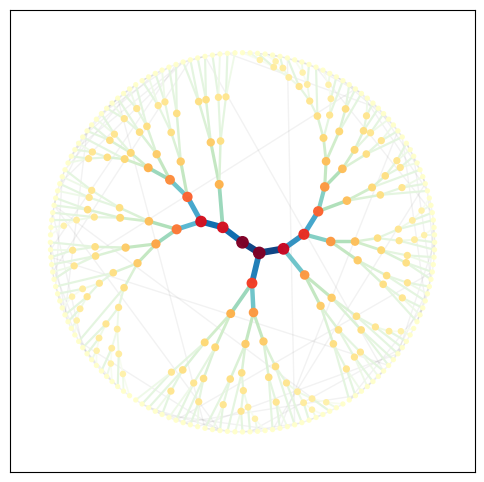

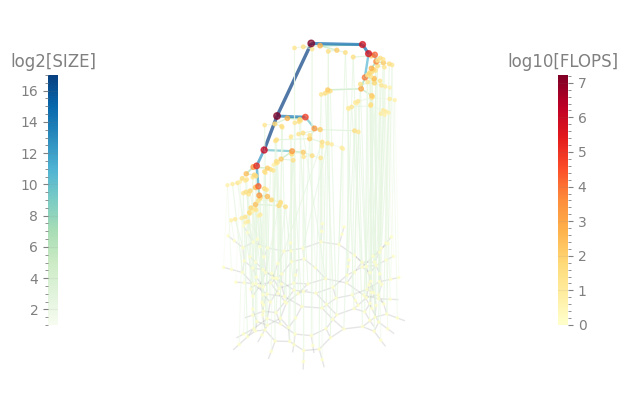


[Step 4B] Optimizing for UPMEM (Limit: 64 MB)...


F=7.36 C=7.65 S=17.00 P=17.81: 100%|██████████| 32/32 [00:00<00:00, 46.16it/s] 


-> UPMEM Max Memory: 2^17.0 elements
-> Total Slices (DPU Tasks): 1
-> Calculation Overhead: 1.00x


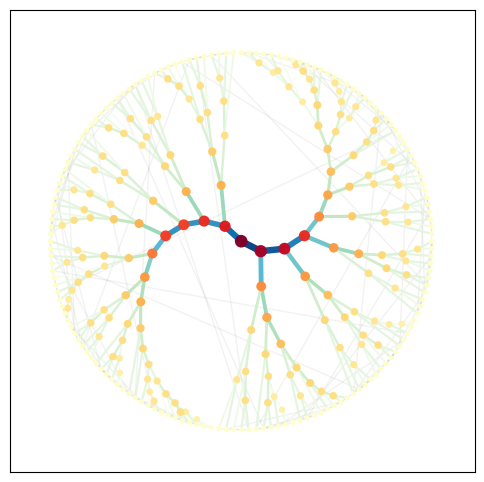

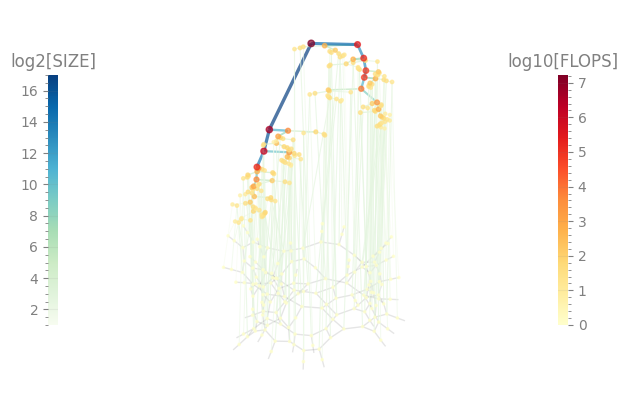

In [8]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices
    print(f"-> Converted! Network has {n_tensors} tensors and {n_indices} indices.")

    # -----------------------------------------------------
    # STEP 2: GEOMETRY VIEW (Physics)
    # -----------------------------------------------------
    G_tn = nx.Graph()
    tensors = [t for t in tn]
    for i in range(len(tensors)):
        G_tn.add_node(i)
        for j in range(i + 1, len(tensors)):
            if set(tensors[i].inds).intersection(tensors[j].inds):
                G_tn.add_edge(i, j)

    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G_tn, seed=42, k=0.15, iterations=50)
    nx.draw(G_tn, pos, node_size=30, node_color='#00d2ff', edge_color='#cccccc', width=0.5)
    plt.title("Tensor Network Geometry\n(Transpiled Circuit Structure)")
    plt.show()

    # -----------------------------------------------------
    # STEP 3A: NAIVE SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3] Attempting Naive Contraction...")
    opt_naive = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_naive = opt_naive.search(inputs, output, size_dict)
        max_mem_naive = math.log2(tree_naive.max_size())
        
        fig, ax = plt.subplots(figsize=(6, 6))
        # --- SAFE PLOT: No edge_alpha ---
        tree_naive.plot_ring(ax=ax)
        tree_naive.plot_tent(order=True)
        ax.set_title(f"Naive Path\nMem: 2^{max_mem_naive:.1f} | Slices: 1")
        plt.show()
    except Exception as e:
        print(f"Naive search failed: {e}")

    # -----------------------------------------------------
    # STEP 3B: CPU SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3B] Attempting CPU Contraction...")
    opt_cpu = ctg.HyperOptimizer(
        methods=['kahypar', 'greedy'],  # Use graph partitioning (requires kahypar) + greedy
        minimize='flops',               # CPU prefers minimizing pure math operations
        max_repeats=32,                # Explore more paths to find the best one
        parallel=True,                  # Use multiple CPU cores to perform the search
        progbar=True
    )
    
    try:
        tree_cpu = opt_cpu.search(inputs, output, size_dict)
        max_mem_cpu = math.log2(tree_cpu.max_size())
        slices = tree_cpu.nslices
        overhead = tree_cpu.total_flops() / tree_cpu.contract_stats()['flops']
        
        print(f"-> UPMEM Max Memory: 2^{max_mem_cpu:.1f} elements")
        print(f"-> Total Slices (DPU Tasks): {slices}")
        print(f"-> Calculation Overhead: {overhead:.2f}x")

        
        fig, ax = plt.subplots(figsize=(6, 6))
        # --- SAFE PLOT: No edge_alpha ---
        tree_cpu.plot_ring(ax=ax)
        tree_cpu.plot_tent(order=True)
        ax.set_title(f"CPU Path\nMem: 2^{max_mem_cpu:.1f} | Slices: {slices}")
        plt.show()
    except Exception as e:
        print(f"CPU search failed: {e}")

    # -----------------------------------------------------
    # STEP 4: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    '''limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmem = opt_upmem.search(inputs, output, size_dict)
    
    max_mem_upmem = math.log2(tree_upmem.max_size())
    slices = tree_upmem.nslices
    overhead = tree_upmem.total_flops() / tree_upmem.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmem:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slices}")
    print(f"-> Calculation Overhead: {overhead:.2f}x")

    fig, ax = plt.subplots(figsize=(6, 6))
    # --- SAFE PLOT: No edge_alpha ---
    tree_upmem.plot_ring(ax=ax)
    tree_upmem.plot_tent(order=True)
    #tree_upmem.plot_flat()
    ax.set_title(f"UPMEM Sliced Path\nMem: 2^{max_mem_upmem:.1f} | Slices: {slices}")
    plt.show()'''

    # -----------------------------------------------------
    # STEP 4B: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4B] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmemB = ctg.HyperOptimizer(
        methods=['kahypar', 'greedy'],  # Use graph partitioning (requires kahypar) + greedy
        minimize='combo',               # CPU prefers minimizing pure math operations
        max_repeats=32,                # Explore more paths to find the best one
        parallel=True,                  # Use multiple CPU cores to perform the search
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmemB = opt_upmemB.search(inputs, output, size_dict)
    
    max_mem_upmemB = math.log2(tree_upmemB.max_size())
    slicesB = tree_upmemB.nslices
    overheadB = tree_upmemB.total_flops() / tree_upmemB.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmemB:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slicesB}")
    print(f"-> Calculation Overhead: {overheadB:.2f}x")

    fig, ax = plt.subplots(figsize=(6, 6))
    # --- SAFE PLOT: No edge_alpha ---
    tree_upmemB.plot_ring(ax=ax)
    tree_upmemB.plot_tent(order=True)
    #tree_upmem.plot_flat()
    ax.set_title(f"UPMEM Sliced Path\nMem: 2^{max_mem_upmemB:.1f} | Slices: {slicesB}")
    plt.show()

# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=64)


VERIFICATION: Calculating Amplitude for |1101001100010011>
-> Projecting output to bitstring...
-> Standardizing Network (Fixing Hyper-Edges)...

[UPMEM Sliced Result]
Optimizing for 0.002 MB limit...
Distributing 4 slices to DPUs...
Optimizer Warning: tuple index out of range. Falling back to exact.

FINAL VERIFICATION REPORT
Qiskit Probability:   0.0005
UPMEM Sliced Prob:    0.0005


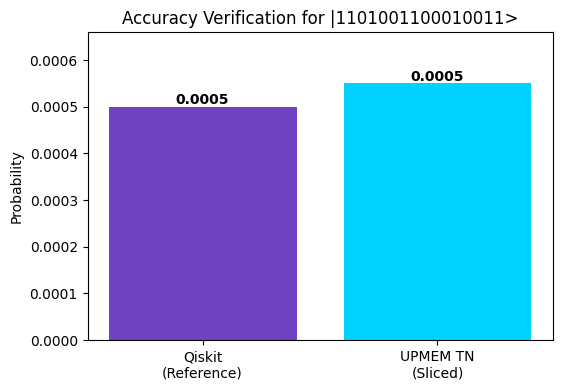

In [ ]:
import numpy as np
import math
import cotengra as ctg
import quimb.tensor as qtn
import matplotlib.pyplot as plt

def verify_upmem_calculation(qiskit_circ, target_bitstring, expected_prob, memory_limit_mb=0.002):
    print(f"\n{'='*60}")
    print(f"VERIFICATION: Calculating Amplitude for |{target_bitstring}>")
    print(f"{'='*60}")
    
    # -----------------------------------------------------
    # 1. SETUP TENSOR NETWORK
    # -----------------------------------------------------
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # Robust Manual Gate Conversion
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        if name in ['barrier', 'measure', 'reset']: continue
        try:
            try:
                qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
            except AttributeError:
                qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except:
            pass

    # Extract clean list of tensors
    # This treats the network as a simple pile of tensors, ignoring graph complexity
    tensor_list = list(circ_quimb.psi)
    
    # -----------------------------------------------------
    # 2. PROJECTION (The List Method)
    # -----------------------------------------------------
    print("-> Projecting output to bitstring...")
    
    for i, bit_char in enumerate(target_bitstring):
        ind_name = f'k{i}' 
        bit_val = int(bit_char)
        
        # Create Projection Vector
        state_vector = np.zeros(2, dtype=complex)
        state_vector[bit_val] = 1.0
        T_proj = qtn.Tensor(data=state_vector, inds=(ind_name,))
        
        # Find the tensor connected to this wire
        target_idx = -1
        for idx, t in enumerate(tensor_list):
            if ind_name in t.inds:
                target_idx = idx
                break
        
        if target_idx != -1:
            # Contract locally (Pure Math)
            tensor_list[target_idx] = tensor_list[target_idx] @ T_proj
            
    # Rebuild Network
    tn = qtn.TensorNetwork(tensor_list)
    
    # -----------------------------------------------------
    # 3. STANDARDIZATION (The Fix for ValueError)
    # -----------------------------------------------------
    print("-> Standardizing Network (Fixing Hyper-Edges)...")
    # This inserts "Copy Tensors" so that every wire connects exactly 2 tensors.
    # This prevents the "index appears more than twice" error.
    '''AttributeErrortry:
        tn.expand_hyper_inds(inplace=True)
    except AttributeError:
        # Fallback for older quimb versions
        tn = tn.resolve_hyper_indices()'''
    
    # Check if network is already solved (Scalar)
    if tn.num_tensors <= 1:
        print("-> Network simplified to a scalar! (No Slicing needed)")
        final_amp = tn.contract() if tn.num_tensors == 1 else 1.0
        sliced_prob = abs(final_amp)**2
        print(f"Result: {sliced_prob:.4f}")
    else:
        # -----------------------------------------------------
        # 4. RUN UPMEM (SLICED) CONTRACTION
        # -----------------------------------------------------
        inputs = [tuple(t.inds) for t in tn]
        output = () 
        size_dict = {i: d for i, d in tn.ind_sizes().items()}
        
        limit_bytes = memory_limit_mb * 1024 * 1024
        # Safety clamp to prevent 0-byte limits
        if limit_bytes < 256: limit_bytes = 256
        target_log2 = math.log2(limit_bytes / 16) 
        
        print(f"\n[UPMEM Sliced Result]")
        print(f"Optimizing for {memory_limit_mb} MB limit...")
        
        opt_upmem = ctg.HyperOptimizer(
            max_repeats=32, 
            progbar=False,
            slicing_opts={'target_size': 2**target_log2} 
        )
        
        try:
            tree_upmem = opt_upmem.search(inputs, output, size_dict)
            
            # SIMULATE DPUs
            arrays = [t.data for t in tn]
            sliced_amp = 0.0 + 0.0j
            num_slices = tree_upmem.nslices
            
            print(f"Distributing {num_slices} slices to DPUs...")
            
            for i in range(num_slices):
                partial_result = tree_upmem.contract_slice(arrays, i=i)
                sliced_amp += partial_result
                
            sliced_prob = abs(sliced_amp)**2
            print(f"Summed Prob: {sliced_prob:.4f}")
            
        except Exception as e:
            print(f"Optimizer Warning: {e}. Falling back to exact.")
            final_amp = tn.contract()
            sliced_prob = abs(final_amp)**2

    # -----------------------------------------------------
    # 5. VISUALIZATION
    # -----------------------------------------------------
    print(f"\n{'='*60}")
    print("FINAL VERIFICATION REPORT")
    print(f"{'='*60}")
    print(f"Qiskit Probability:   {expected_prob:.4f}")
    print(f"UPMEM Sliced Prob:    {sliced_prob:.4f}")
    
    labels = ['Qiskit\n(Reference)', 'UPMEM TN\n(Sliced)']
    values = [expected_prob, sliced_prob]
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=['#6f42c1', '#00d2ff'])
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", 
                 ha='center', va='bottom', fontweight='bold')
                 
    plt.title(f"Accuracy Verification for |{target_bitstring}>")
    plt.ylabel("Probability")
    plt.ylim(0, max(values) * 1.2)
    plt.show()

# =========================================================
# RUN
# =========================================================
top_bitstring_str = list(final_distribution_bin.keys())[0] 
top_prob = list(final_distribution_bin.values())[0]

# Run Verification
verify_upmem_calculation(
    optimized_circuit, 
    target_bitstring=top_bitstring_str[::-1], 
    expected_prob=top_prob,
    memory_limit_mb=64
)